<h1 align="center"><b>Classification(Crop Predictor)</b></h1>
<h2 align="center"> - Manju Varshikha S </h2>

LIBRARIES

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


DATASET OVERVIEW

In [13]:
crop_data = pd.read_csv("data/Crop_recommendation.csv")
crop_data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [14]:
crop_data.shape

(2200, 8)

In [15]:
crop_data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Missing & Duplicate Analysis

In [16]:
print("\nMissing Values:\n", crop_data.isnull().sum())


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [17]:
print("\nDuplicate Rows:", crop_data.duplicated().sum())


Duplicate Rows: 0


In [18]:
crop_data = crop_data.drop_duplicates().reset_index(drop=True)
crop_data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


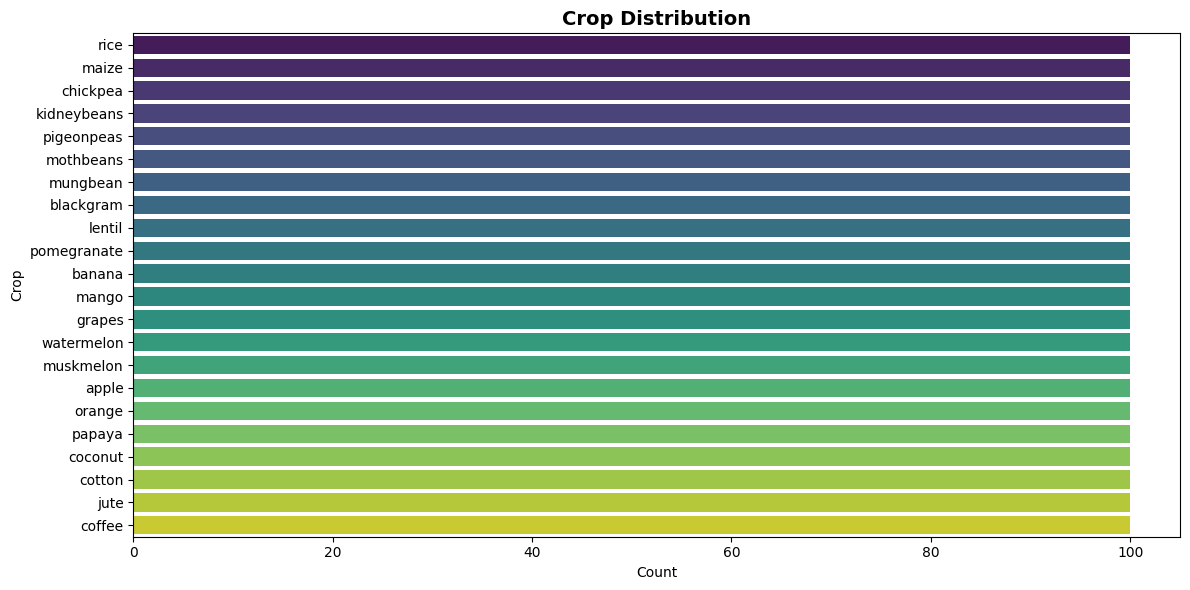

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(
    y=crop_data["label"],
    order=crop_data["label"].value_counts().index,
    palette="viridis"
)
plt.title("Crop Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


CORRELATION HEATMAP

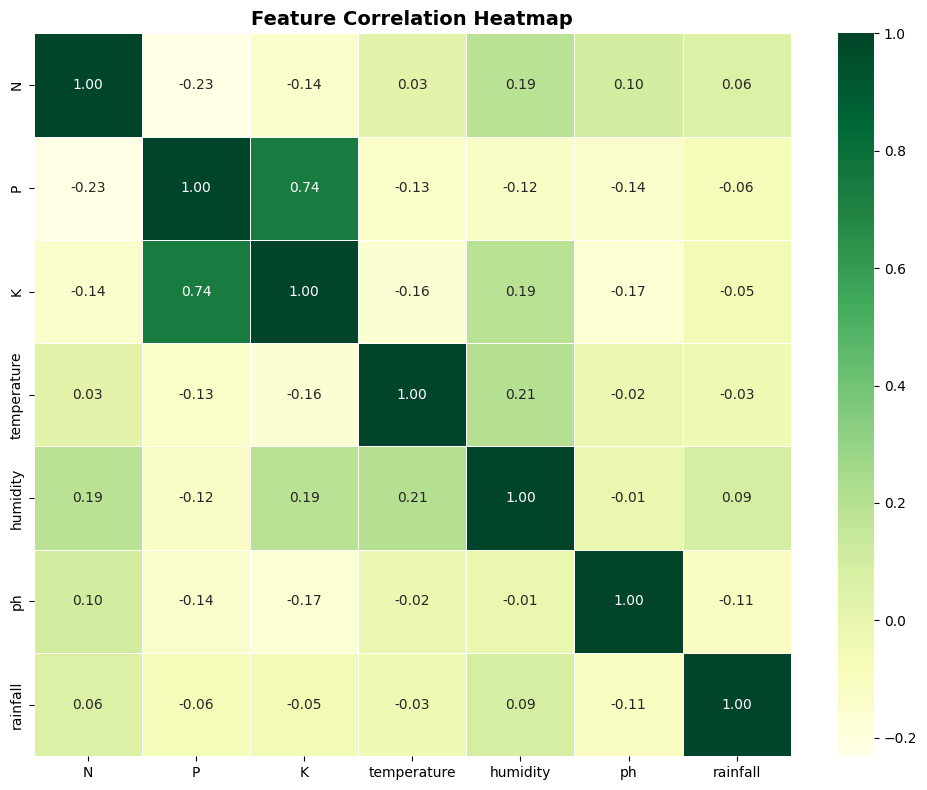

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(
    crop_data.drop(columns=["label"]).corr(),
    annot=True,
    cmap="YlGn",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

MODEL TRAINING

In [21]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [22]:
X = crop_data.drop("label", axis=1)
y = crop_data["label"]

In [23]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Total Crops:", len(label_encoder.classes_))
print("Crop Classes:", label_encoder.classes_)

Total Crops: 22
Crop Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. LOGISTIC REGRESSION

In [26]:
log_model = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_log, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.9727272727272728

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      o

RANDOM FOREST

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


Random Forest Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange 

CONFUSION MATRIX

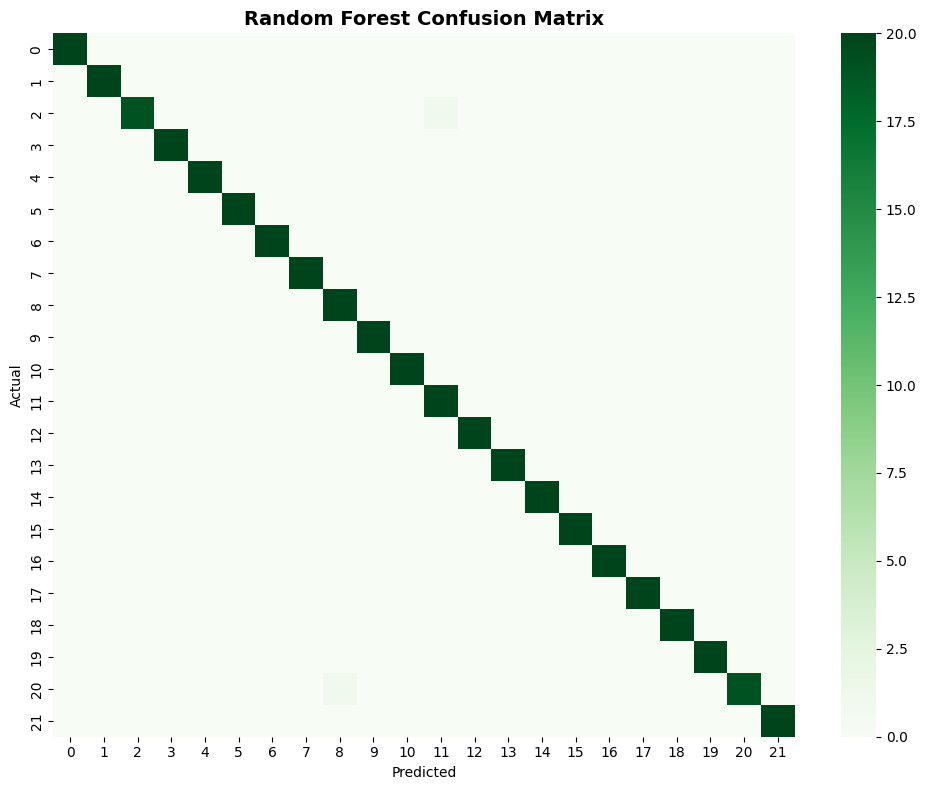

In [28]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    cmap="Greens",
    annot=False
)
plt.title("Random Forest Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE

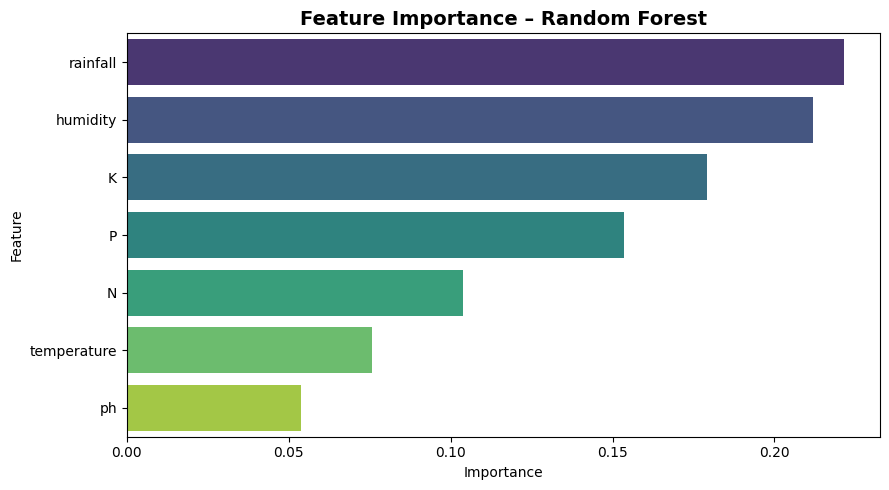

In [29]:
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Feature Importance – Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

SAMPLE PREDICTION

In [34]:
sample_input = {
    "N": 71,
    "P": 54,
    "K": 16,
    "temperature": 22.61359953,
    "humidity": 63.69070564,
    "ph": 5.749914421,
    "rainfall": 87.75953857
}

In [35]:
sample_df = pd.DataFrame([sample_input])
sample_scaled = scaler.transform(sample_df)

pred_encoded = rf_model.predict(sample_scaled)[0]
pred_crop = label_encoder.inverse_transform([pred_encoded])[0]
print("\nPredicted Crop:", pred_crop)



Predicted Crop: maize


In [36]:
probs = rf_model.predict_proba(sample_scaled)[0]

top3_indices = np.argsort(probs)[-3:][::-1]

print("TOP-3 RECOMMENDED CROPS")
for i, idx in enumerate(top3_indices, start=1):
    crop = label_encoder.inverse_transform([idx])[0]
    confidence = probs[idx] * 100
    print(f"{i}. {crop} → {confidence:.2f}% suitability")


TOP-3 RECOMMENDED CROPS
1. maize → 99.33% suitability
2. pigeonpeas → 0.33% suitability
3. mothbeans → 0.33% suitability


In [38]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/crop_final.pkl")
joblib.dump(scaler, "models/scaler_final.pkl")
joblib.dump(label_encoder, "models/encoder_final.pkl")

print("Model, scaler, encoder saved")

Model, scaler, encoder saved
